## Exploratory Data Analysis (EDA)

Este notebook realiza el análisis exploratorio del corpus canónico generado por `ingest.py`.

**Prerrequisito:** haber ejecutado `python src/ingest.py` para generar `data/corpus_canonical_v1.jsonl`

Pasos que cubre este notebook:
- Resumen estadístico básico del corpus
- Extracción y frecuencia de hashtags
- Detección de multimedia (imágenes y vídeos)
- Visualizaciones básicas

In [1]:
# Instalacion de Librerias
#%pip install seaborn

In [1]:
#1 Importacion de Librerias

import pandas as pd               # Manipulación y análisis de datos; DataFrame, lectura/escritura CSV/JSON
import numpy as np                # Operaciones numéricas y arrays; utilidades estadísticas y matemáticas
import matplotlib.pyplot as plt   # Visualización básica; crear figuras, ejes y guardar gráficos
import seaborn as sns             # Visualizaciones estadísticas de alto nivel; estilos y gráficos complejos
import re                         # Librería para trabajar con expresiones regulares
import os                         # Libreria para navegar en los directorios de Windows

In [2]:
# =======================================================================
# 1. Cargar corpus canónico generado por ingest.py
# Este archivo es el punto de partida del EDA.
# Debe existir antes de ejecutar este notebook.

# Subir un nivel: de notebooks/ a la raíz del repositorio
os.chdir("..")

corpus_path = "data/corpus_canonical_v1.jsonl"

df_es = pd.read_json(corpus_path, lines=True)

print(f"✅ Corpus cargado correctamente: {len(df_es)} tweets en español")

✅ Corpus cargado correctamente: 6437 tweets en español


In [3]:
# =======================================================================
# 2. Vista preliminar de los datos
# Revisamos las primeras filas para entender la estructura del corpus canónico.

print("\n=== Vista preliminar del corpus ===")
print(df_es.head())


=== Vista preliminar del corpus ===
   followers_count  friends_count  account_created_at          created_at  \
0              362             28 2018-10-27 17:11:00 2022-12-11 14:53:00   
1              122            376 2021-12-10 06:08:00 2022-12-11 14:53:00   
2              136           1849 2017-10-27 10:23:00 2022-12-11 14:53:00   
3              149            167 2021-07-05 21:11:00 2022-12-11 14:53:00   
4            26986            886 2014-04-30 18:56:00 2022-12-11 14:53:00   

                                           full_text  truncated  \
0  RT @eldestapeweb: 🔴 La FIFA abrió un expedient...      False   
1  RT @estarc62: En el 66 insultando a la reina, ...      False   
2  EL PUBLICO SE RENUEVAya lo dijo Chiquita Legra...      False   
3  RT @edufeiok: A estos de Países Bajos también ...      False   
4  #AN7Deportes| FIFA busca sancionar a Argentina...      False   

                source  in_reply_to_status_id  in_reply_to_user_id  \
0      Twitter Web App     

In [4]:
# =======================================================================
# 3. Dimensiones y tipos de datos
# shape devuelve número de filas y columnas.
# dtypes muestra el tipo de dato de cada columna (numérico, texto, etc.).

print("\n=== Dimensiones y tipos de datos ===")
print("Dimensiones:", df_es.shape)
print("\nTipos de datos:\n", df_es.dtypes)


=== Dimensiones y tipos de datos ===
Dimensiones: (6437, 17)

Tipos de datos:
 followers_count                     int64
friends_count                       int64
account_created_at         datetime64[us]
created_at                 datetime64[us]
full_text                             str
truncated                            bool
source                                str
in_reply_to_status_id             float64
in_reply_to_user_id               float64
in_reply_to_screen_name               str
is_quote_status                      bool
retweet_count                       int64
favorite_count                      int64
favorited                            bool
retweeted                            bool
lang                                  str
tweet_id_hashed                       str
dtype: object


In [5]:
# =======================================================================
# 4. Estadísticas básicas
# describe() genera estadísticas descriptivas de columnas numéricas
# y con include="all" también incluye categóricas.

print("\n=== Estadísticas básicas ===")
print(df_es.describe(include="all"))


=== Estadísticas básicas ===
        followers_count  friends_count          account_created_at  \
count      6.437000e+03    6437.000000                        6437   
unique              NaN            NaN                         NaN   
top                 NaN            NaN                         NaN   
freq                NaN            NaN                         NaN   
mean       5.754823e+04    1397.372844  2016-11-09 20:25:18.446481   
min        0.000000e+00       0.000000         2007-03-27 09:42:00   
25%        2.800000e+01      98.000000         2012-01-05 20:44:00   
50%        1.840000e+02     326.000000         2017-09-08 05:02:00   
75%        9.600000e+02     935.000000         2021-07-08 20:02:00   
max        1.066164e+07  651128.000000         2022-12-11 13:39:00   
std        4.696230e+05   12553.718087                         NaN   

                        created_at  \
count                         6437   
unique                         NaN   
top            

# RESUMEN ESTADÍSTICO BÁSICO

In [6]:
# 5. =======================================================================
# RESUMEN ESTADISTICO BASICO

print("\n=== RESUMEN ESTADISTICO BASICO ===\n")

# Columnas del corpus canónico
print("\n=== Columnas del corpus canónico ===\n")
print(df_es.columns.tolist())

# Número total de tweets
print("\nTotal de tweets en español:", len(df_es))

# Distribución por idioma (aunque ya filtramos, sirve para verificar)
print("\n=== Distribución por idioma ===")
print(df_es['lang'].value_counts())

# Longitud promedio de los tweets (usar 'full_text')
df_es['tweet_length'] = df_es['full_text'].apply(lambda x: len(str(x)))
print("\n=== Longitud promedio de los tweets ===")
print(df_es['tweet_length'].mean())


# 5.1. =======================================================================
# EXTRACCIÓN DE HASHTAGS Y MULTIMEDIA DESDE EL TEXTO

# Extraer hashtags directamente del texto de los tweets usando regex
# La expresión r"#\w+" busca cualquier palabra precedida por el símbolo #
df_es['extracted_hashtags'] = df_es['full_text'].apply(
    lambda x: re.findall(r"#\w+", str(x))
)

# Unimos todas las listas de hashtags en una sola lista
all_hashtags = df_es['extracted_hashtags'].sum()

# Convertimos la lista en una Serie de pandas para poder contar frecuencias
hashtags_series = pd.Series(all_hashtags)

# Mostramos los 10 hashtags más frecuentes en el corpus
print("\n=== Top 10 hashtags más frecuentes ===")
print(hashtags_series.value_counts().head(10))

# Detectar enlaces a imágenes en el texto
# 'pic.twitter.com' es el patrón típico de imágenes compartidas en tweets
df_es['has_image'] = df_es['full_text'].apply(lambda x: 'pic.twitter.com' in str(x))

# Detectar enlaces a videos en el texto
# Buscamos palabras clave como 'video' o enlaces a YouTube ('youtu')
df_es['has_video'] = df_es['full_text'].apply(
    lambda x: 'video' in str(x).lower() or 'youtu' in str(x).lower()
)

# Mostramos el conteo de tweets que contienen multimedia
print("\n=== Tweets con multimedia detectada ===")
print("Con imagen:", df_es['has_image'].sum())
print("Con video:", df_es['has_video'].sum())


"""
# Hashtags más frecuentes (solo si existe la columna 'hashtags')
if 'hashtags' in df_es.columns:
    try:
        # Convertir listas de hashtags en una sola lista
        all_hashtags = df_es['hashtags'].dropna().apply(eval).sum()
        hashtags_series = pd.Series(all_hashtags)
        print("\n=== Top 10 hashtags más frecuentes ===")
        print(hashtags_series.value_counts().head(10))
    except Exception as e:
        print("Error procesando hashtags:", e)

# Tweets con imágenes y videos (solo si existen esas columnas)
if 'is_image' in df_es.columns and 'is_video' in df_es.columns:
    print("\n=== Tweets con multimedia ===")
    print("Con imagen:", df_es['is_image'].astype(int).sum())
    print("Con video:", df_es['is_video'].astype(int).sum())
"""


=== RESUMEN ESTADISTICO BASICO ===


=== Columnas del corpus canónico ===

['followers_count', 'friends_count', 'account_created_at', 'created_at', 'full_text', 'truncated', 'source', 'in_reply_to_status_id', 'in_reply_to_user_id', 'in_reply_to_screen_name', 'is_quote_status', 'retweet_count', 'favorite_count', 'favorited', 'retweeted', 'lang', 'tweet_id_hashed']

Total de tweets en español: 6437

=== Distribución por idioma ===
lang
es    6437
Name: count, dtype: int64

=== Longitud promedio de los tweets ===
161.91424576666148

=== Top 10 hashtags más frecuentes ===
#Qatar2022           293
#FIFA                134
#FIFAWorldCup         97
#MacriMufa            50
#VTV                  36
#Argentina            35
#fifa                 33
#ARG                  30
#TUMundial            29
#MundialTelemundo     26
Name: count, dtype: int64

=== Tweets con multimedia detectada ===
Con imagen: 0
Con video: 135


'\n# Hashtags más frecuentes (solo si existe la columna \'hashtags\')\nif \'hashtags\' in df_es.columns:\n    try:\n        # Convertir listas de hashtags en una sola lista\n        all_hashtags = df_es[\'hashtags\'].dropna().apply(eval).sum()\n        hashtags_series = pd.Series(all_hashtags)\n        print("\n=== Top 10 hashtags más frecuentes ===")\n        print(hashtags_series.value_counts().head(10))\n    except Exception as e:\n        print("Error procesando hashtags:", e)\n\n# Tweets con imágenes y videos (solo si existen esas columnas)\nif \'is_image\' in df_es.columns and \'is_video\' in df_es.columns:\n    print("\n=== Tweets con multimedia ===")\n    print("Con imagen:", df_es[\'is_image\'].astype(int).sum())\n    print("Con video:", df_es[\'is_video\'].astype(int).sum())\n'

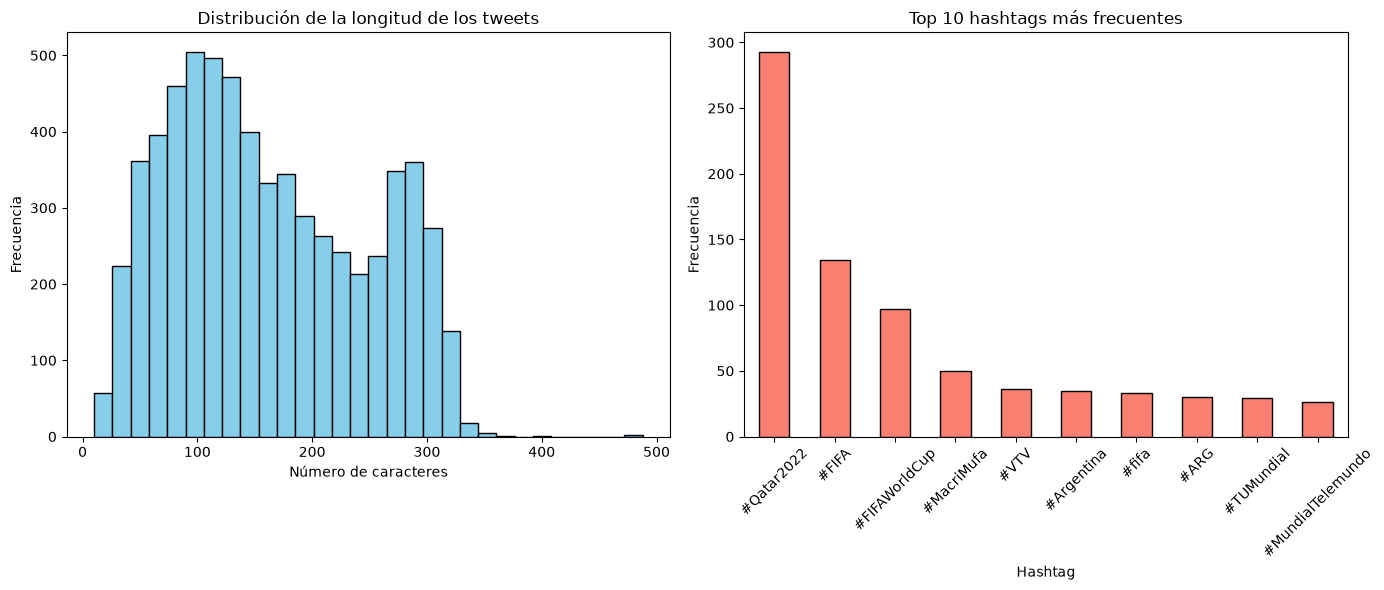

In [7]:
# 6. =======================================================================
# VISUALIZACIONES BÁSICAS

# VISUALIZACIÓN COMBINADA: LONGITUDES DE TWEETS + HASHTAGS FRECUENTES

# --- Preparar datos para hashtags ---
# Unimos todas las listas de hashtags en una sola lista
all_hashtags = df_es['extracted_hashtags'].sum()

# Convertimos la lista en una Serie de pandas para contar frecuencias
hashtags_series = pd.Series(all_hashtags)

# Seleccionamos los 10 hashtags más frecuentes
top_hashtags = hashtags_series.value_counts().head(10)

# --- Crear figura con dos subplots ---
plt.figure(figsize=(14,6))  # Definimos tamaño general de la figura

# Subplot 1: Histograma de longitudes de tweets
plt.subplot(1,2,1)  # 1 fila, 2 columnas, posición 1
plt.hist(df_es['tweet_length'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribución de la longitud de los tweets")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")

# Subplot 2: Gráfico de barras de hashtags más frecuentes
plt.subplot(1,2,2)  # 1 fila, 2 columnas, posición 2
top_hashtags.plot(kind='bar', color='salmon', edgecolor='black')
plt.title("Top 10 hashtags más frecuentes")
plt.xlabel("Hashtag")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)

# Ajustamos el diseño para que no se solapen los gráficos
plt.tight_layout()

# Mostramos la figura completa
plt.show()